In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
order = pd.read_csv('../data/order_clean.csv')
products = pd.read_csv('../data/products_clean.csv')
marketing = pd.read_csv('../data/marketing_clean.csv')


order['order_date'] = pd.to_datetime(order['order_date'])
marketing['month_dt'] = pd.to_datetime(marketing['month'])

print(f"Order    : {order.shape}")
print(f"Products : {products.shape}")
print(f"Marketing: {marketing.shape}")

Order    : (1997, 26)
Products : (207, 9)
Marketing: (144, 11)


In [6]:
category=order.groupby('primary_category').agg(
    total_orders=('order_id','count'),
    total_revenue=('gross_revenue','sum'),
    total_discount=('discount_amount','sum'),
    total_shipping=('shipping_cost','sum'),
    total_product_cost=('product_cost','sum'),
    total_platform_fee=('refund_amount','sum'),
    total_refund=('refund_amount','sum'),
    total_profit=('profit','sum'),
    avg_profit_margin=('profit_margin_%','mean'),
    return_rate=('returned_binary','mean')
).reset_index()


category['return_rate_%']=(category['return_rate']*100).round(2)

category['total_profit_margin_%']=(category['total_profit']/category['total_revenue']*100).round(2)

category=category.sort_values('total_profit_margin_%',ascending=True)
print(category[['primary_category', 'total_orders', 'total_revenue',
 'total_profit', 'total_profit_margin_%',
 'return_rate_%']].to_string(index=False))

primary_category  total_orders  total_revenue  total_profit  total_profit_margin_%  return_rate_%
           Books           238       22360.48       2236.04                  10.00           8.40
          Beauty           204       20672.65       3104.48                  15.02           5.88
        Clothing           293       37515.60       6272.48                  16.72           8.19
          Sports           292       37453.25       7596.63                  20.28           7.19
 Food & Beverage           247       36878.52       7591.77                  20.59           5.67
  Home & Kitchen           200       30879.43       6688.57                  21.66           6.00
            Toys           256       39011.88       8756.12                  22.44           7.03
     Electronics           267       52876.49      13973.46                  26.43           8.61


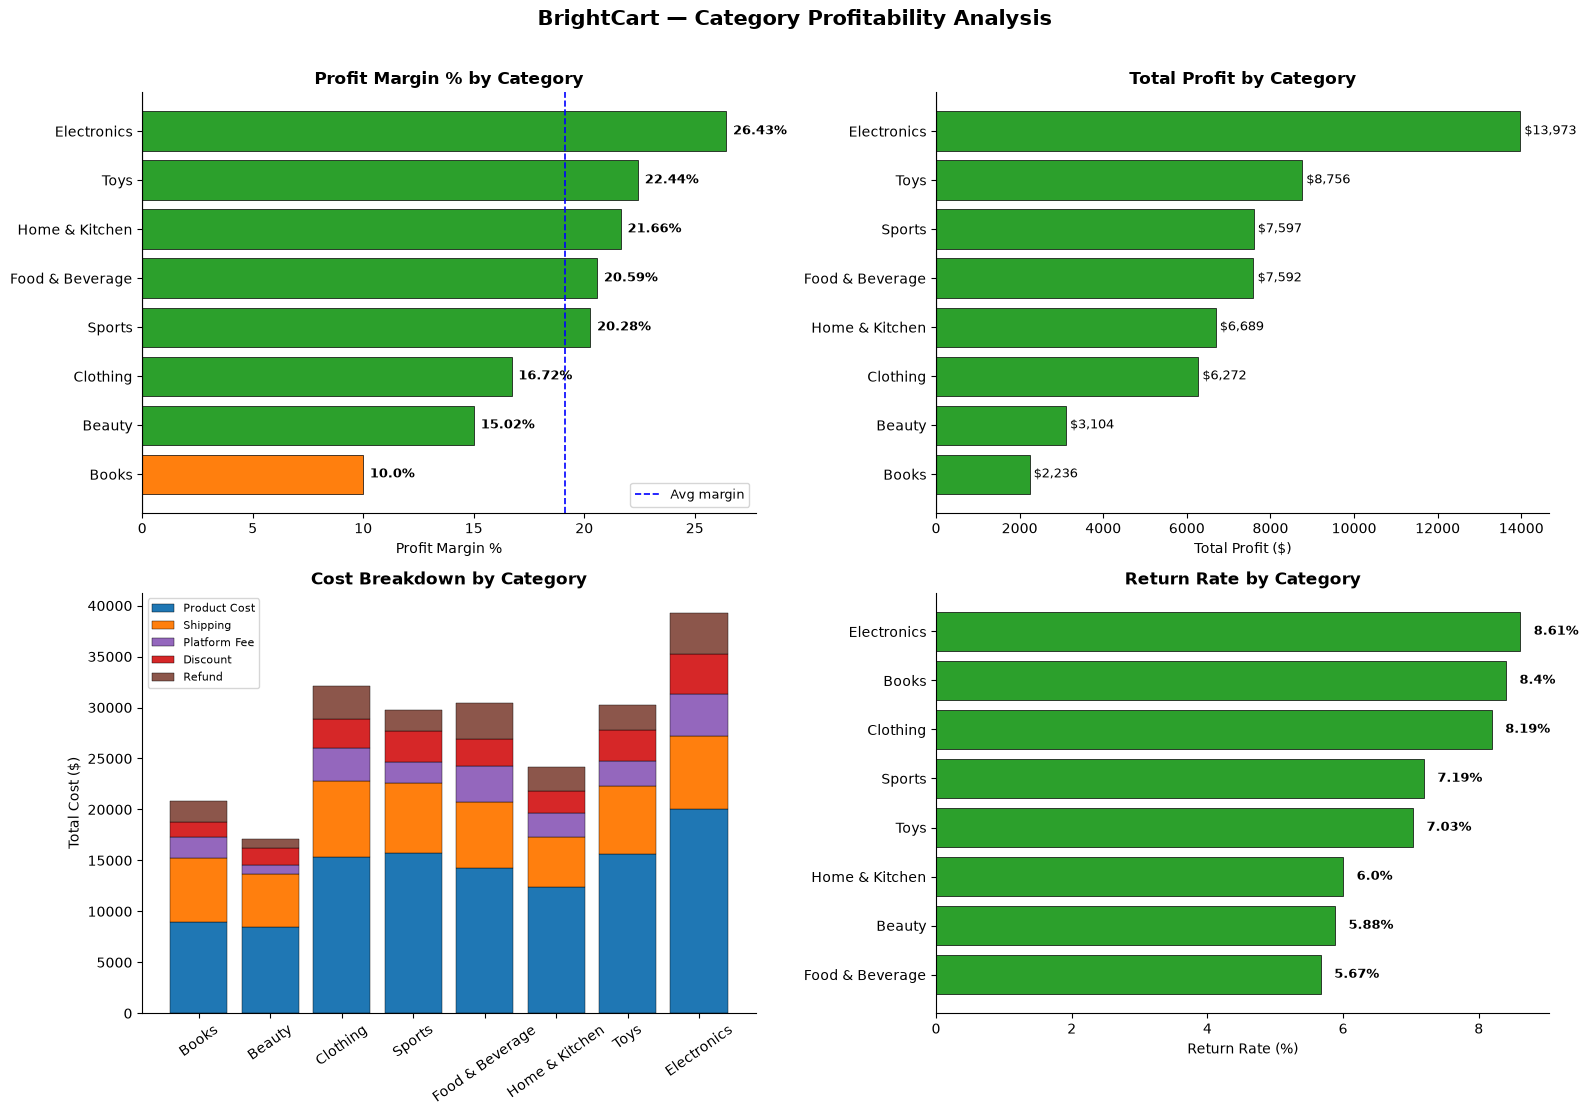

In [16]:
fig,axes=plt.subplots(2,2,figsize=(16,11))
fig.suptitle('BrightCart — Category Profitability Analysis',
      fontsize=15,fontweight='bold',y=1.01

)
cat_sorted=category.sort_values('total_profit_margin_%',ascending=True)
colors = ['#d62728' if x < 0 else '#ff7f0e' if x < 15
          else '#2ca02c' for x in cat_sorted['total_profit_margin_%']]

bars=axes[0,0].barh(
    cat_sorted['primary_category'],
    cat_sorted['total_profit_margin_%'],
    color=colors,edgecolor='black',linewidth=0.5
)

axes[0,0].axvline(0,color='black',linewidth=0.8)
axes[0,0].axvline(cat_sorted['total_profit_margin_%'].mean(),
color='blue',linestyle='--',linewidth=1.2,label='Avg margin'
)
for bar, val in zip(bars, cat_sorted['total_profit_margin_%']):
    axes[0,0].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                   f'{val}%', va='center', fontsize=9, fontweight='bold')

axes[0,0].set_title('Profit Margin % by Category', fontweight='bold')
axes[0,0].set_xlabel('Profit Margin %')
axes[0,0].legend(fontsize=9)
axes[0,0].spines['top'].set_visible(False)
axes[0,0].spines['right'].set_visible(False)



cat_profit = category.sort_values('total_profit', ascending=True)
colors2 = ['#d62728' if x < 0 else '#2ca02c'
           for x in cat_profit['total_profit']]

bars2 = axes[0,1].barh(cat_profit['primary_category'],
                        cat_profit['total_profit'],
                        color=colors2, edgecolor='black', linewidth=0.5)
axes[0,1].axvline(0, color='black', linewidth=0.8)
for bar, val in zip(bars2, cat_profit['total_profit']):
    axes[0,1].text(val + 100, bar.get_y() + bar.get_height()/2,
                   f'${val:,.0f}', va='center', fontsize=9)
axes[0,1].set_title('Total Profit by Category', fontweight='bold')
axes[0,1].set_xlabel('Total Profit ($)')
axes[0,1].spines['top'].set_visible(False)
axes[0,1].spines['right'].set_visible(False)


cat_cost = category.set_index('primary_category')
cost_cols = ['total_product_cost', 'total_shipping',
             'total_platform_fee', 'total_discount', 'total_refund']
cost_labels = ['Product Cost', 'Shipping',
               'Platform Fee', 'Discount', 'Refund']
cost_colors = ['#1f77b4', '#ff7f0e', '#9467bd', '#d62728', '#8c564b']

bottom = pd.Series([0] * len(cat_cost), index=cat_cost.index)
for col, label, color in zip(cost_cols, cost_labels, cost_colors):
    axes[1,0].bar(cat_cost.index, cat_cost[col],
                  bottom=bottom, label=label,
                  color=color, edgecolor='black', linewidth=0.3)
    bottom += cat_cost[col]

axes[1,0].set_title('Cost Breakdown by Category', fontweight='bold')
axes[1,0].set_ylabel('Total Cost ($)')
axes[1,0].tick_params(axis='x', rotation=35)
axes[1,0].legend(fontsize=8)
axes[1,0].spines['top'].set_visible(False)
axes[1,0].spines['right'].set_visible(False)



# ── Panel 4: Return Rate by Category
cat_return = category.sort_values('return_rate_%', ascending=True)
colors3 = ['#d62728' if x > 15 else '#ff7f0e' if x > 10
           else '#2ca02c' for x in cat_return['return_rate_%']]

bars3 = axes[1,1].barh(cat_return['primary_category'],
                        cat_return['return_rate_%'],
                        color=colors3, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars3, cat_return['return_rate_%']):
    axes[1,1].text(val + 0.2, bar.get_y() + bar.get_height()/2,
                   f'{val}%', va='center', fontsize=9, fontweight='bold')
axes[1,1].set_title('Return Rate by Category', fontweight='bold')
axes[1,1].set_xlabel('Return Rate (%)')
axes[1,1].spines['top'].set_visible(False)
axes[1,1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/chart1_category_profitability.png',
            dpi=150, bbox_inches='tight')
plt.show()

### 📊 Chart 1 — Category Profitability Insight

**Profit Margin Ranking:**
| Category | Margin | Status |
|---|---|---|
| Electronics | 26.43% | 🟢 Best performer |
| Toys | 22.44% | 🟢 Strong |
| Home & Kitchen | 21.66% | 🟢 Strong |
| Food & Beverage | 20.59% | 🟢 Strong |
| Sports | 20.28% | 🟢 Strong |
| Clothing | 16.72% | 🟠 Below average |
| Beauty | 15.02% | 🟠 Below average |
| Books | 10.00% | 🔴 Weakest — needs review |

**Key Findings:**
- Electronics generates 26.43% margin and $13,973 total profit —
  the single most valuable category despite high product costs
- Books has the lowest margin at 10% — driven by high shipping
  costs relative to low average selling price
- Beauty has the lowest return rate (5.88%) but still underperforms
  on margin — discount strategy is likely eroding profitability
- No category is loss-making at aggregate level — but 563 individual
  orders across all categories are unprofitable (28.15%)
- Average margin across all categories: ~19%

**What's driving the difference:**
- High margin: High selling price relative to product cost (Electronics, Toys)
- Low margin: High shipping cost relative to revenue (Books)
  or high discount usage (Beauty, Clothing)

**Recommendation:**
- Double down on Electronics and Toys — highest margin + high volume
- Review Books pricing strategy — increase selling price or
  introduce free shipping threshold to improve margin
- Audit Beauty discount policy — returns are low so the
  product is good, discounts are the problem